In [1]:
import pandas as pd
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from keras.initializers import HeNormal

c:\Users\Cpu\anaconda3\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
import os
os.path.exists(r"C:\Users\Cpu\Downloads\car_purchasing.csv")


True

In [3]:


df = pd.read_csv(
    r"C:\Users\Cpu\Downloads\car_purchasing.csv",
    encoding='latin1'
)




In [18]:
df.head()


,customer name,customer e-mail,country,gender,age,annual Salary,credit card debt,net worth,car purchase amount
0,Martina Avila,cubilia.Curae.Phasellus@quisaccumsanconvallis.edu,Bulgaria,0,41.851720,62812.09301,11609.380910,238961.2505,35321.45877
1,Harlan Barnes,eu.dolor@diam.co.uk,Belize,0,40.870623,66646.89292,9572.957136,530973.9078,45115.52566
2,Naomi Rodriquez,vulputate.mauris.sagittis@ametconsectetueradip...,Algeria,1,43.152897,53798.55112,11160.355060,638467.1773,42925.70921
3,Jade Cunningham,malesuada@dignissim.com,Cook Islands,1,58.271369,79370.03798,14426.164850,548599.0524,67422.36313
4,Cedric Leach,felis.ullamcorper.viverra@egetmollislectus.net,Brazil,1,57.313749,59729.15130,5358.712177,560304.0671,55915.46248


In [19]:
df.shape

(500, 9)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer name        500 non-null    object 
 1   customer e-mail      500 non-null    object 
 2   country              500 non-null    object 
 3   gender               500 non-null    int64  
 4   age                  500 non-null    float64
 5   annual Salary        500 non-null    float64
 6   credit card debt     500 non-null    float64
 7   net worth            500 non-null    float64
 8   car purchase amount  500 non-null    float64
dtypes: float64(5), int64(1), object(3)
memory usage: 35.3+ KB


In [22]:
df.duplicated().sum()


np.int64(0)

In [26]:
X = df.drop('car purchase amount', axis=1)
y = df['car purchase amount']


In [27]:
X.head()

,gender,age,annual Salary,credit card debt,net worth
0,0,41.851720,62812.09301,11609.380910,238961.2505
1,0,40.870623,66646.89292,9572.957136,530973.9078
2,1,43.152897,53798.55112,11160.355060,638467.1773
3,1,58.271369,79370.03798,14426.164850,548599.0524
4,1,57.313749,59729.15130,5358.712177,560304.0671


In [28]:
y.head()

0    35321.45877
1    45115.52566
2    42925.70921
3    67422.36313
4    55915.46248
Name: car purchase amount, dtype: float64

In [30]:
X.columns


Index(['gender', 'age', 'annual Salary', 'credit card debt', 'net worth'], dtype='object')

In [37]:
#Training set and Test set

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [38]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)


In [42]:
#make the ANN!
import keras
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LeakyReLU,PReLU,ELU
from keras.layers import Dropout

In [44]:
# Initialising the ANN


classifier = Sequential()

# Input layer + first hidden layer
classifier.add(Dense(
    units=6,
    kernel_initializer='he_uniform',
    activation='relu',
    input_dim=X_train.shape[1]
))
# Second hidden layer
classifier.add(Dense(
    units=6,
    kernel_initializer='he_uniform',
    activation='relu'
))
classifier.add(Dense(
    units=1,
    kernel_initializer='glorot_uniform'
))
classifier.compile(
    optimizer='Adam',
    loss='mean_squared_error'
)
model_history = classifier.fit(
    X_train,
    y_train,
    validation_split=0.33,
    batch_size=10,
    epochs=10
)

Epoch 1/10


c:\Users\Cpu\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2079039360.0000 - val_loss: 1987016320.0000
Epoch 2/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2079000192.0000 - val_loss: 1986979328.0000
Epoch 3/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2078960128.0000 - val_loss: 1986940672.0000
Epoch 4/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2078917632.0000 - val_loss: 1986899968.0000
Epoch 5/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2078870656.0000 - val_loss: 1986854784.0000
Epoch 6/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2078818048.0000 - val_loss: 1986803712.0000
Epoch 7/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2078757888.0000 - val_loss: 1986744448.0000
Epoch 8/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2078690176.0000 - val_loss: 1986675712.0000
Epoch 9/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2078609920.0000 - val_loss: 1986598272.0000
Epoch 10/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2078518016.0000 - val_loss: 198650

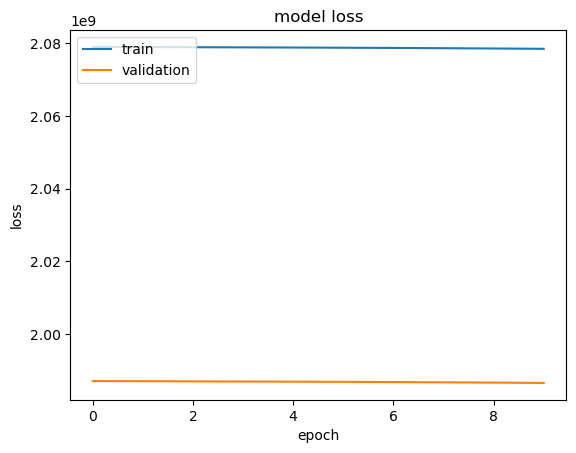

In [45]:
import matplotlib.pyplot as plt

plt.plot(model_history.history['loss'])
plt.plot(model_history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

In [47]:
from sklearn.metrics import r2_score, mean_squared_error

print("R2 Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))


R2 Score: -18.97512061670901
MSE: 2156776884.6707563


In [52]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)


Mean Squared Error: 2156776884.6707563
R2 Score: -18.97512061670901
